# **проект №3: Онлайн-школа**

### Анализ посещений, регистраций и рекламных кампаний

## 1. Введение и подготовка окружения

Проект посвящён анализу данных о посещениях, регистрациях и рекламных кампаниях образовательной платформы с использованием Python и Jupyter Notebook.

## 2. Подготовка к работе с данными

Исходные данные проекта содержат информацию о посещениях и регистрациях пользователей образовательной платформы.

Данные о посещениях включают идентификатор пользователя, платформу, User-Agent и дату визита. Данные о регистрациях содержат идентификатор пользователя, электронную почту, платформу, тип регистрации и дату события.

Основной анализ выполняется на данных, полученных через API за заданный период.

## 3. Запросы к API

Загружаем необходимые библиотеки и переменные окружения, задающие адрес API и период исследования.

Получаем данные о посещениях и регистрациях через API и сохраняем ответы в датафреймы для дальнейшей обработки.

In [5]:
import os

import pandas as pd
import requests
from dotenv import load_dotenv

# переменные окружения
load_dotenv()
API_URL = os.getenv("API_URL")
DATE_BEGIN = os.getenv("DATE_BEGIN")
DATE_END = os.getenv("DATE_END")

# посещения
visits_response = requests.get(f"{API_URL}/visits", params={"begin": DATE_BEGIN, "end": DATE_END})
visits_response.raise_for_status()
visits = pd.DataFrame(visits_response.json())

# регистрации
registrations_response = requests.get(f"{API_URL}/registrations", params={"begin": DATE_BEGIN, "end": DATE_END})
registrations_response.raise_for_status()
registrations = pd.DataFrame(registrations_response.json())

## 4. Расчёт метрик

Подготавливаем данные для расчёта ключевых метрик: исключаем бот-трафик и для каждого пользователя оставляем последнее посещение перед дальнейшей агрегацией.

Группируем посещения и регистрации по дате и платформе, рассчитываем конверсию как отношение числа регистраций к числу посещений. Полученный набор данных сохраняем в `conversion.json`.

In [7]:
# преобразование дат
visits["datetime"] = pd.to_datetime(visits["datetime"])
registrations["datetime"] = pd.to_datetime(registrations["datetime"])

# фильтрация ботов и последнее посещение
visits = visits[~visits["user_agent"].str.contains("bot", case=False, na=False)]
visits = visits.sort_values("datetime").drop_duplicates("visit_id", keep="last")

# группировка
visits["date_group"] = visits["datetime"].dt.floor("D")
registrations["date_group"] = registrations["datetime"].dt.floor("D")

# посещения и регистрации
visits_daily = visits.groupby(["date_group", "platform"]).size().reset_index(name="visits")
registrations_daily = registrations.groupby(["date_group", "platform"]).size().reset_index(name="registrations")

# конверсия
conversion = visits_daily.merge(registrations_daily, on=["date_group", "platform"], how="left")
conversion["registrations"] = conversion["registrations"].fillna(0).astype(int)
conversion["conversion"] = conversion["registrations"] / conversion["visits"] * 100
conversion = conversion.sort_values(["date_group", "platform"]).reset_index(drop=True)

conversion.to_json("./conversion.json")

## 5. Рекламные кампании

Загружаем данные о рекламных кампаниях и приводим даты к единому формату для сопоставления с посещениями и регистрациями.

Объединяем рекламные расходы с ежедневными показателями активности. Для дней без рекламных кампаний указываем нулевые расходы и отсутствие кампании. Полученный набор данных сохраняем в `ads.json`.

In [9]:
# рекламные данные
ads = pd.read_csv("./ads.csv")
if "date" not in ads.columns:
    ads = pd.read_csv("./ads.csv", names=["date", "utm_source", "utm_medium", "utm_campaign", "cost"])

# преобразование дат
ads["date"] = pd.to_datetime(ads["date"])
ads["date_group"] = ads["date"].dt.floor("D")

# посещения и регистрации
daily_totals = conversion.groupby("date_group", as_index=False)[["visits", "registrations"]].sum()

# объединение
ads_df = daily_totals.merge(ads[["date_group", "utm_campaign", "cost"]], on="date_group", how="left")
ads_df["cost"] = ads_df["cost"].fillna(0).astype(int)
ads_df["utm_campaign"] = ads_df["utm_campaign"].fillna("none")
ads_df = ads_df[["date_group", "visits", "registrations", "cost", "utm_campaign"]].sort_values("date_group").reset_index(drop=True)

ads_df.to_json("./ads.json")

## 6. Визуализация

Визуализируем динамику посещений, регистраций и конверсии за исследуемый период, включая распределение показателей по платформам.

Отдельно анализируем рекламные расходы и сопоставляем периоды активности рекламных кампаний с изменением числа посещений и регистраций. Полученные графики сохраняем в каталоге `charts`.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

os.makedirs("./charts", exist_ok=True)

### Общее количество посещений

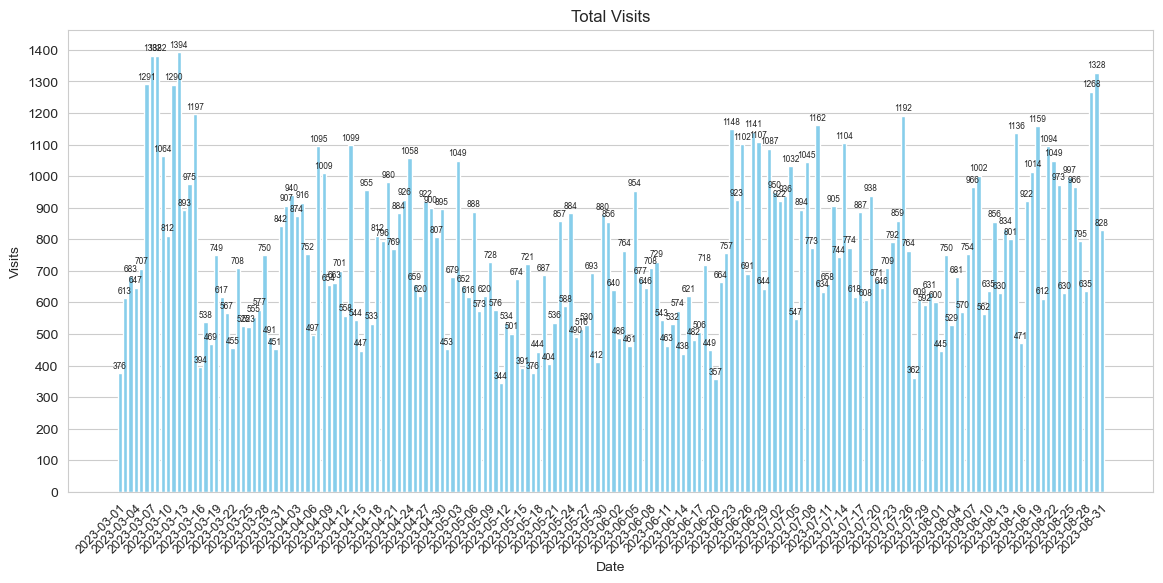

In [13]:
# по дням
total_visits = conversion.groupby("date_group", as_index=False)["visits"].sum()

plt.figure(figsize=(14, 6))
plt.bar(total_visits["date_group"], total_visits["visits"], color="skyblue")

# значения
for date, value in zip(total_visits["date_group"], total_visits["visits"]):
    plt.annotate(str(value), (date, value), xytext=(0, 2), textcoords="offset points", ha="center", va="bottom", fontsize=6)

# подписи
date_ticks = pd.date_range(total_visits["date_group"].min(), total_visits["date_group"].max(), freq="3D")
plt.xticks(date_ticks, [date.strftime("%Y-%m-%d") for date in date_ticks], rotation=45, ha="right", rotation_mode="anchor", fontsize=9)

plt.title("Total Visits")
plt.xlabel("Date")
plt.ylabel("Visits")
plt.grid(axis="x", visible=False)
plt.yticks(range(0, int(total_visits["visits"].max()) + 101, 100))

plt.savefig("./charts/total_visits.png", bbox_inches="tight")
plt.show()

### Посещения по платформам

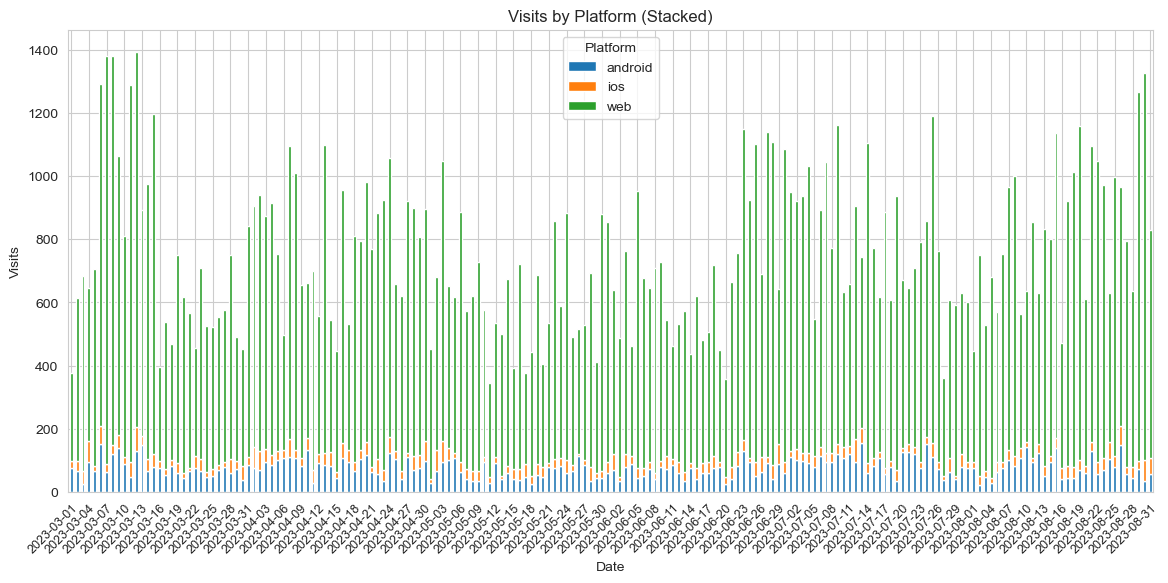

In [15]:
visits_by_platform = conversion.pivot(index="date_group", columns="platform", values="visits").fillna(0)
visits_by_platform.index = visits_by_platform.index.strftime("%Y-%m-%d")

ax = visits_by_platform.plot(kind="bar", stacked=True, figsize=(14, 6))

tick_positions = range(0, len(visits_by_platform), 3)
tick_labels = [visits_by_platform.index[i] for i in tick_positions]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=9)

ax.set_title("Visits by Platform (Stacked)")
ax.set_xlabel("Date")
ax.set_ylabel("Visits")
ax.legend(title="Platform")

plt.savefig("./charts/visits_by_platform.png", bbox_inches="tight")
plt.show()

### Общее количество регистраций

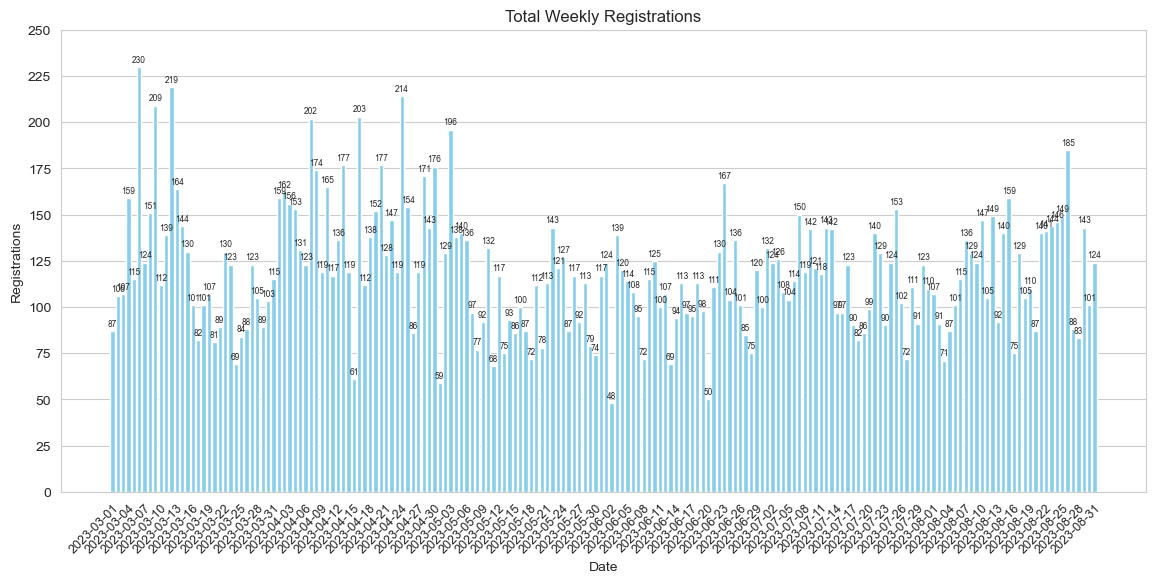

In [17]:
# по дням
total_registrations = conversion.groupby("date_group", as_index=False)["registrations"].sum()

plt.figure(figsize=(14, 6))
plt.bar(total_registrations["date_group"], total_registrations["registrations"], color="skyblue")

for date, value in zip(total_registrations["date_group"], total_registrations["registrations"]):
    plt.annotate(str(value), (date, value), xytext=(0, 2), textcoords="offset points", ha="center", va="bottom", fontsize=6)

date_ticks = pd.date_range(total_registrations["date_group"].min(), total_registrations["date_group"].max(), freq="3D")
plt.xticks(date_ticks, [date.strftime("%Y-%m-%d") for date in date_ticks], rotation=45, ha="right", rotation_mode="anchor", fontsize=9)

plt.title("Total Weekly Registrations")
plt.xlabel("Date")
plt.ylabel("Registrations")
plt.grid(axis="x", visible=False)
plt.yticks(range(0, int(total_registrations["registrations"].max()) + 26, 25))

plt.savefig("./charts/total_registrations.png", bbox_inches="tight")
plt.show()

### Регистрации по платформам

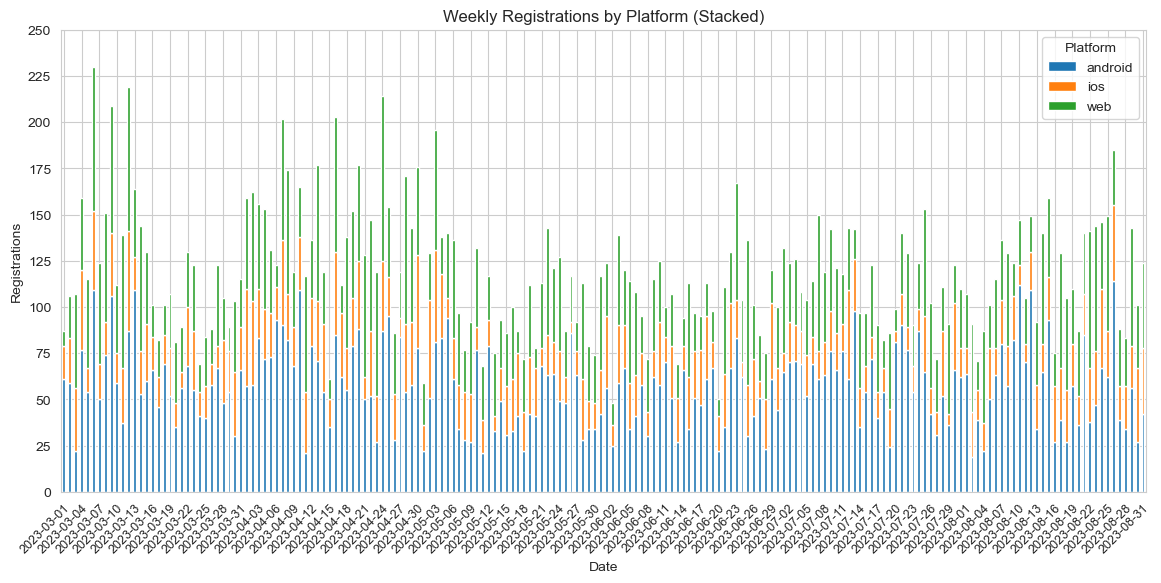

In [19]:
registrations_by_platform = conversion.pivot(index="date_group", columns="platform", values="registrations").fillna(0)
registrations_by_platform.index = registrations_by_platform.index.strftime("%Y-%m-%d")

ax = registrations_by_platform.plot(kind="bar", stacked=True, figsize=(14, 6))

tick_positions = range(0, len(registrations_by_platform), 3)
tick_labels = [registrations_by_platform.index[i] for i in tick_positions]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=9)

ax.set_title("Weekly Registrations by Platform (Stacked)")
ax.set_xlabel("Date")
ax.set_ylabel("Registrations")
ax.legend(title="Platform")
ax.set_yticks(range(0, int(registrations_by_platform.sum(axis=1).max()) + 26, 25))

plt.savefig("./charts/registrations_by_platform.png", bbox_inches="tight")
plt.show()

### Общая конверсия

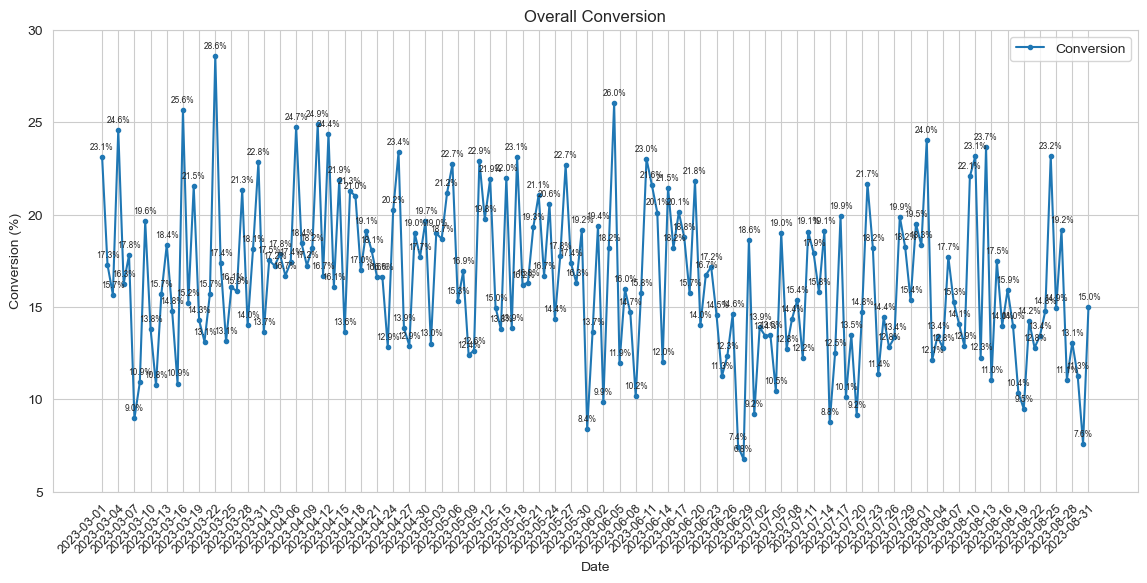

In [21]:
overall_conversion = conversion.groupby("date_group", as_index=False)[["visits", "registrations"]].sum()
overall_conversion["conversion"] = overall_conversion["registrations"] / overall_conversion["visits"] * 100

plt.figure(figsize=(14, 6))
plt.plot(overall_conversion["date_group"], overall_conversion["conversion"], marker="o", markersize=3, label="Conversion")

for date, value in zip(overall_conversion["date_group"], overall_conversion["conversion"]):
    plt.annotate(f"{value:.1f}%", (date, value), xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=6)

date_ticks = pd.date_range(overall_conversion["date_group"].min(), overall_conversion["date_group"].max(), freq="3D")
plt.xticks(date_ticks, [date.strftime("%Y-%m-%d") for date in date_ticks], rotation=45, ha="right", rotation_mode="anchor", fontsize=9)

plt.title("Overall Conversion")
plt.xlabel("Date")
plt.ylabel("Conversion (%)")
plt.legend()
plt.ylim(5, 30)
plt.yticks(range(5, 31, 5))

plt.savefig("./charts/overall_conversion.png", bbox_inches="tight")
plt.show()

### Конверсия по платформам

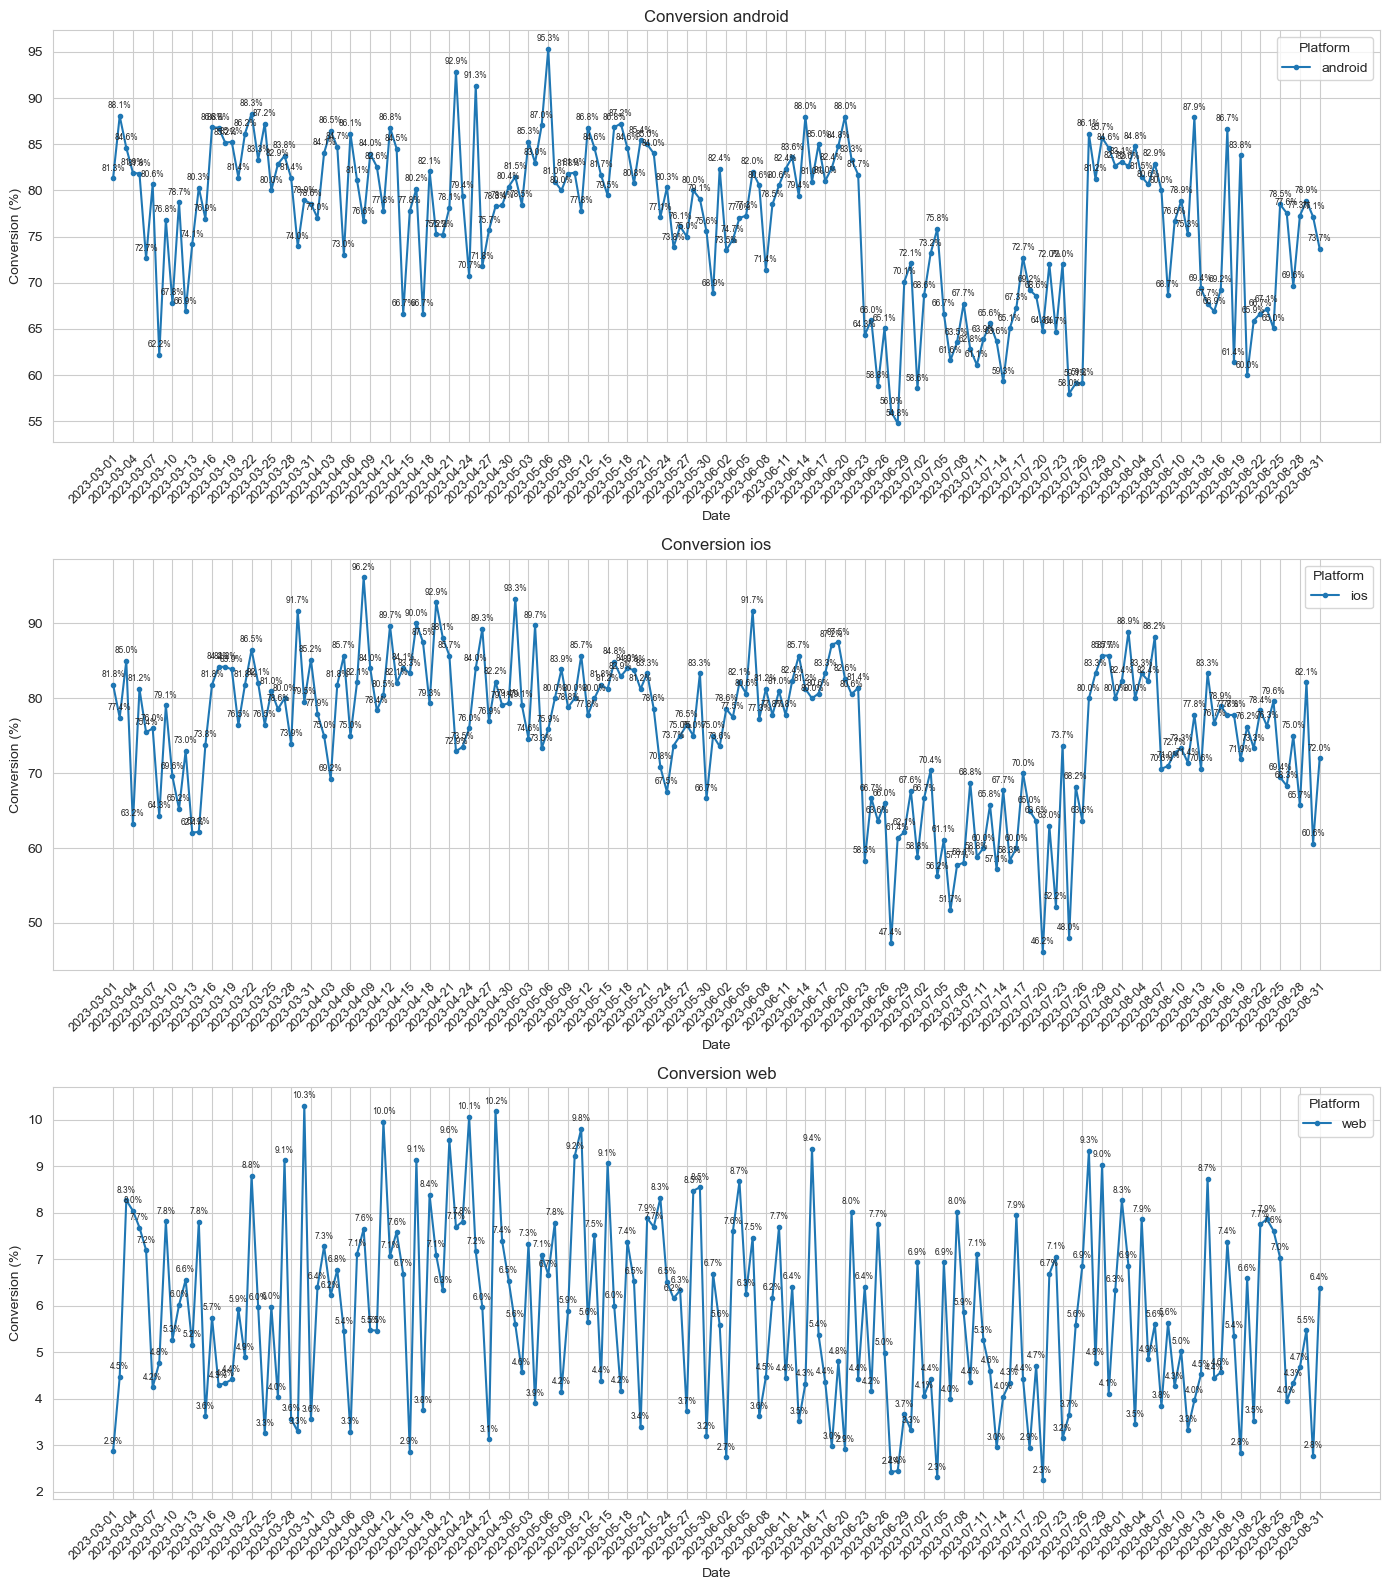

In [23]:
conversion_by_platform = conversion.pivot(index="date_group", columns="platform", values="conversion")

fig, axes = plt.subplots(3, 1, figsize=(14, 16))

for ax, platform in zip(axes, ["android", "ios", "web"]):
    values = conversion_by_platform[platform]
    ax.plot(conversion_by_platform.index, values, marker="o", markersize=3, label=platform)

    # значения
    for date, value in values.items():
        ax.annotate(f"{value:.1f}%", (date, value), xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=6)

    # подписи
    date_ticks = pd.date_range(conversion_by_platform.index.min(), conversion_by_platform.index.max(), freq="3D")
    ax.set_xticks(date_ticks)
    ax.set_xticklabels([date.strftime("%Y-%m-%d") for date in date_ticks], rotation=45, ha="right", rotation_mode="anchor", fontsize=9)

    ax.set_title(f"Conversion {platform}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Conversion (%)")
    ax.legend(title="Platform")

plt.tight_layout()
plt.savefig("./charts/conversion_by_platform.png", bbox_inches="tight")
plt.show()

### Расходы на рекламу

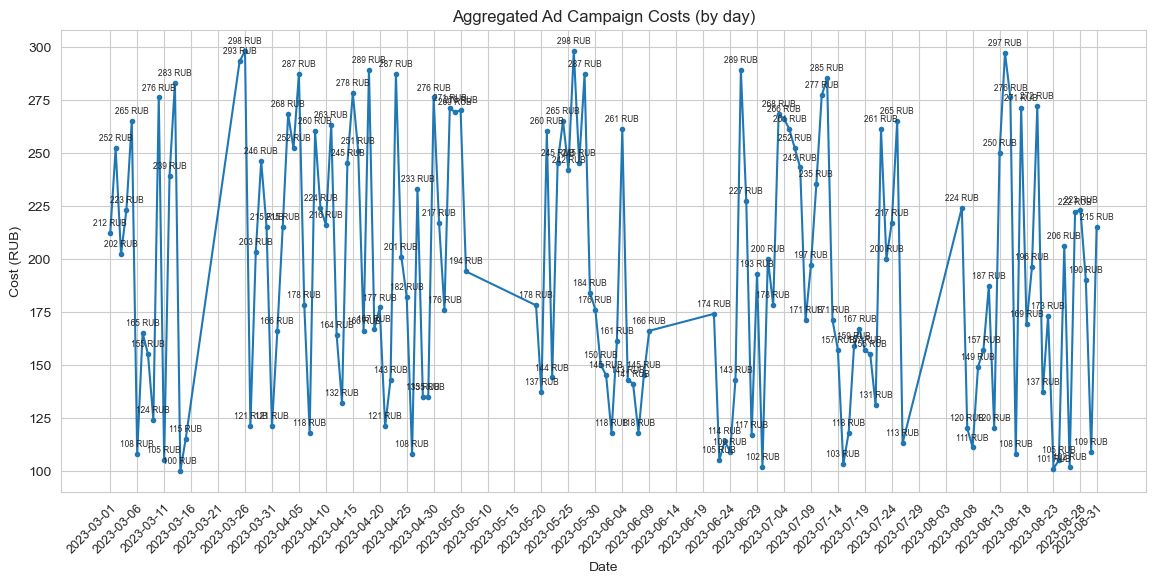

In [25]:
ad_costs = ads_df[ads_df["cost"] > 0].groupby("date_group", as_index=False)["cost"].sum()

plt.figure(figsize=(14, 6))
plt.plot(ad_costs["date_group"], ad_costs["cost"], marker="o", markersize=3)

for date, value in zip(ad_costs["date_group"], ad_costs["cost"]):
    plt.annotate(f"{value} RUB", (date, value), xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=6)

date_ticks = pd.date_range(ad_costs["date_group"].min(), ad_costs["date_group"].max(), freq="5D")

if date_ticks[-1] != ad_costs["date_group"].max():
    date_ticks = date_ticks.append(pd.DatetimeIndex([ad_costs["date_group"].max()]))

plt.xticks(date_ticks, [date.strftime("%Y-%m-%d") for date in date_ticks], rotation=45, ha="right", rotation_mode="anchor", fontsize=9)

plt.title("Aggregated Ad Campaign Costs (by day)")
plt.xlabel("Date")
plt.ylabel("Cost (RUB)")

plt.savefig("./charts/ad_costs.png", bbox_inches="tight")
plt.show()

### Посещения в периоды рекламных кампаний

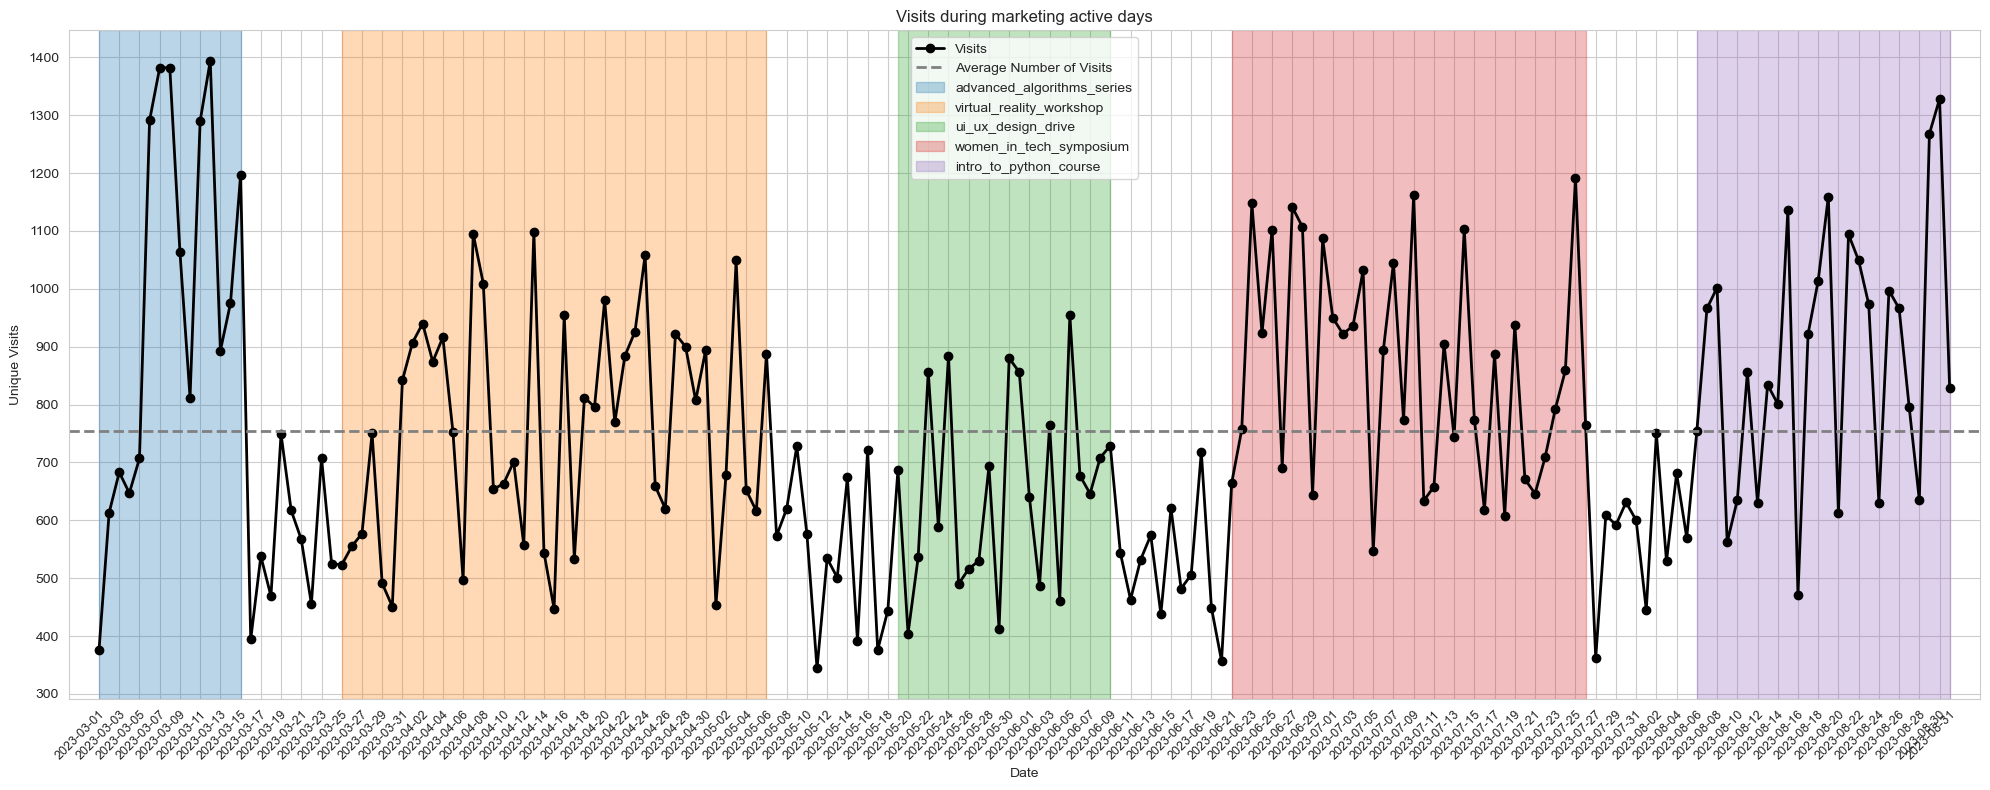

In [27]:
fig, ax = plt.subplots(figsize=(20, 8))

ax.plot(ads_df["date_group"], ads_df["visits"], color="black", marker="o", linewidth=2, label="Visits")
ax.axhline(ads_df["visits"].mean(), color="gray", linestyle="--", linewidth=2, label="Average Number of Visits")

campaigns = [c for c in ads_df["utm_campaign"].unique() if c != "none"]
colors = plt.cm.tab10.colors

for i, campaign in enumerate(campaigns):
    dates = ads_df.loc[ads_df["utm_campaign"] == campaign, "date_group"]
    ax.axvspan(dates.min(), dates.max(), color=colors[i], alpha=0.3, label=campaign)

first_date = ads_df["date_group"].min()
last_date = ads_df["date_group"].max()
date_ticks = pd.date_range(first_date, last_date, freq="2D")

if date_ticks[-1] != last_date:
    date_ticks = date_ticks.append(pd.DatetimeIndex([last_date]))

ax.set_xticks(date_ticks)
ax.set_xticklabels([date.strftime("%Y-%m-%d") for date in date_ticks], rotation=45, ha="right", rotation_mode="anchor", fontsize=9)
ax.set_xlim(first_date - pd.Timedelta(days=3), last_date + pd.Timedelta(days=3))

# горизонтально
y_max = int(ads_df["visits"].max() // 100 + 1) * 100
ax.set_yticks(range(300, y_max + 1, 100))

ax.set_title("Visits during marketing active days")
ax.set_xlabel("Date")
ax.set_ylabel("Unique Visits")
ax.legend()

plt.tight_layout()
plt.savefig("./charts/visits_with_campaigns.png", bbox_inches="tight")
plt.show()

### Регистрации в периоды рекламных кампаний

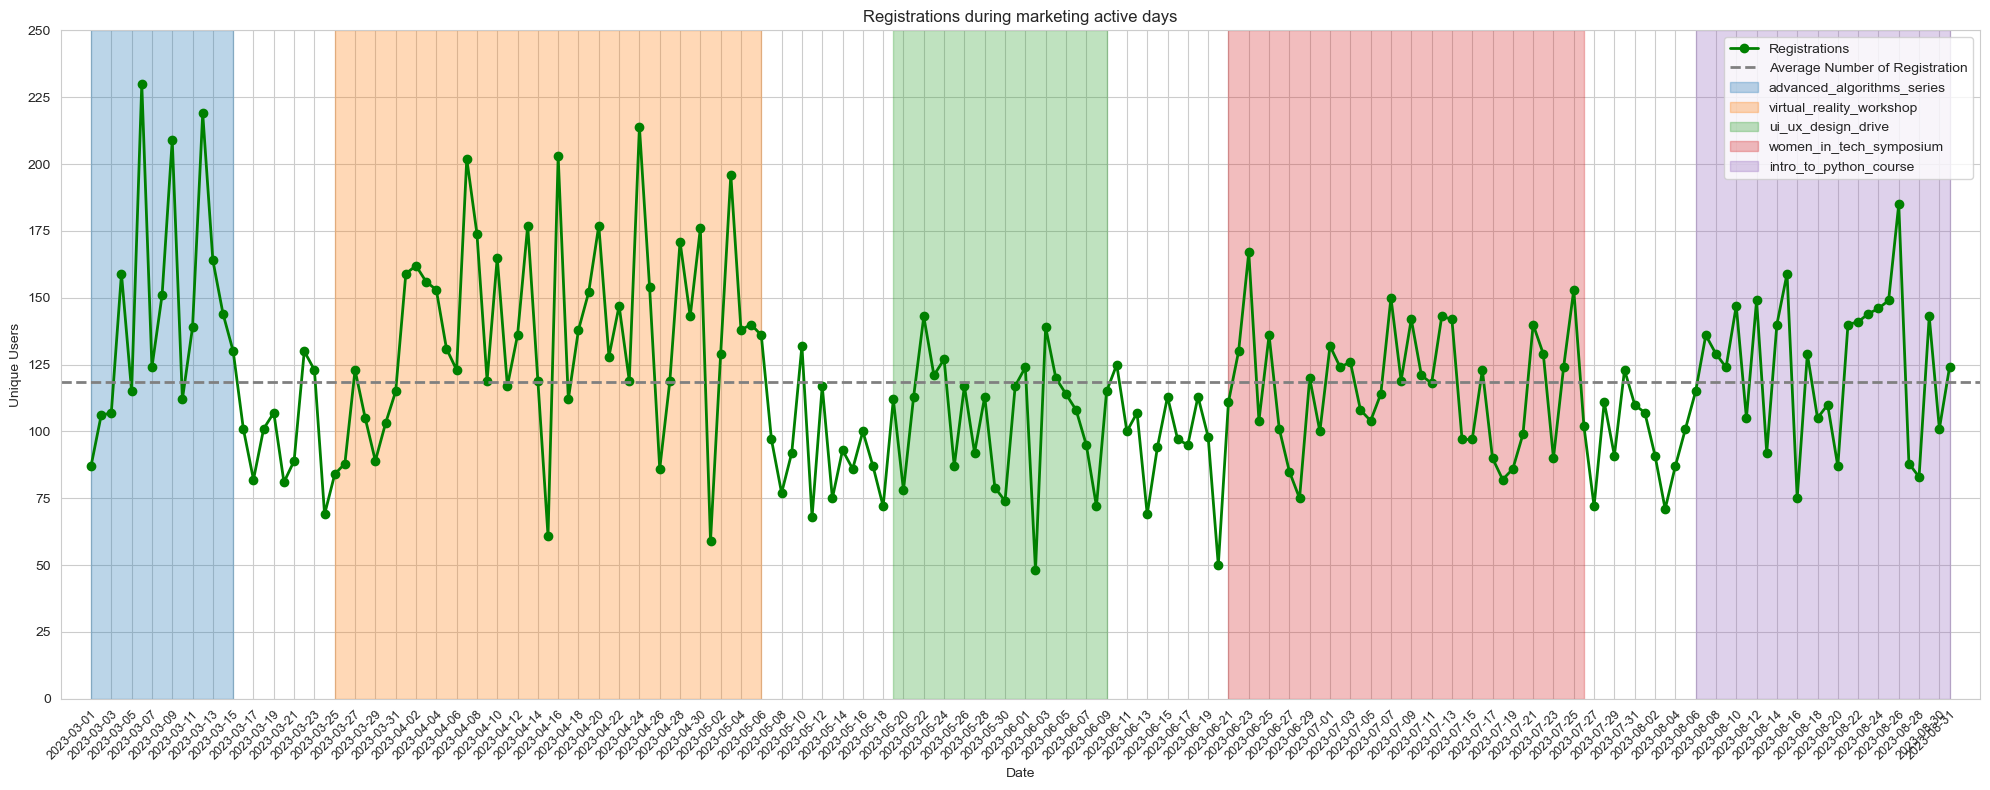

In [29]:
fig, ax = plt.subplots(figsize=(20, 8))

ax.plot(ads_df["date_group"], ads_df["registrations"], color="green", marker="o", linewidth=2, label="Registrations")
ax.axhline(ads_df["registrations"].mean(), color="gray", linestyle="--", linewidth=2, label="Average Number of Registration")

# рекламные кампании
campaigns = [c for c in ads_df["utm_campaign"].unique() if c != "none"]
colors = plt.cm.tab10.colors

for i, campaign in enumerate(campaigns):
    dates = ads_df.loc[ads_df["utm_campaign"] == campaign, "date_group"]
    ax.axvspan(dates.min(), dates.max(), color=colors[i], alpha=0.3, label=campaign)

first_date = ads_df["date_group"].min()
last_date = ads_df["date_group"].max()
date_ticks = pd.date_range(first_date, last_date, freq="2D")

if date_ticks[-1] != last_date:
    date_ticks = date_ticks.append(pd.DatetimeIndex([last_date]))

ax.set_xticks(date_ticks)
ax.set_xticklabels([date.strftime("%Y-%m-%d") for date in date_ticks], rotation=45, ha="right", rotation_mode="anchor", fontsize=9)
ax.set_xlim(first_date - pd.Timedelta(days=3), last_date + pd.Timedelta(days=3))

y_max = int(ads_df["registrations"].max() // 25 + 1) * 25
ax.set_yticks(range(0, y_max + 1, 25))

ax.set_title("Registrations during marketing active days")
ax.set_xlabel("Date")
ax.set_ylabel("Unique Users")
ax.legend()

plt.tight_layout()
plt.savefig("./charts/registrations_with_campaigns.png", bbox_inches="tight")
plt.show()

## 7. Тестирование

Проверяем воспроизводимость анализа: корректность загрузки переменных окружения и исходных данных, создание итоговых JSON-файлов и сохранение визуализаций.

Ноутбук выполняется последовательно от начала до конца и формирует все необходимые результаты проекта.

## 8. Презентация и выводы

На основе полученных результатов оцениваем влияние рекламных кампаний на посещения, регистрации и конверсию образовательной платформы.

В разделе выполняются дополнительные расчёты и формируются визуальные материалы для итоговой презентации.